In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyDOE2 import lhs
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

In [3]:
def branin(x1, x2):
    """
    The Branin function - our pretend expensive simulation.
    Inputs: x1 in [-5, 10], x2 in [0, 15]
    """
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    
    result = a*(x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s
    return result

# Quick sanity check - run it at one point to make sure it works
test_output = branin(1.0, 1.0)
print(f"Branin at (1.0, 1.0) = {test_output:.4f}")

Branin at (1.0, 1.0) = 27.7029


In [5]:
# How many "simulation runs" we can afford
n_samples = 20

# Latin Hypercube Sampling gives us 20 points
# spread evenly across the space (smarter than random)
lhs_samples = lhs(2, samples=n_samples)

# Scale from [0,1] to actual input ranges
# x1: [-5, 10], x2: [0, 15]
X = np.zeros_like(lhs_samples)
X[:, 0] = lhs_samples[:, 0] * 15 - 5   # x1 range
X[:, 1] = lhs_samples[:, 1] * 15        # x2 range

# Evaluate the "simulation" at these 20 points
y = np.array([branin(X[i,0], X[i,1]) for i in range(n_samples)])

print(f"Sample points shape: {X.shape}")
print(f"Output values shape: {y.shape}")
print(f"Min output: {y.min():.2f}, Max output: {y.max():.2f}")

Sample points shape: (20, 2)
Output values shape: (20,)
Min output: 4.09, Max output: 141.48


In [7]:
# Define the kernel - this controls how the GP interpolates
kernel = C(1.0) * RBF(length_scale=[1.0, 1.0])

# Create the GP model
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)

# Train it on our 20 sample points
gp.fit(X, y)

print("GP trained successfully!")
print(f"Optimized kernel: {gp.kernel_}")


GP trained successfully!
Optimized kernel: 3.29**2 * RBF(length_scale=[3.8, 12.1])


In [9]:
# Create a dense grid of 2500 points to evaluate
n_grid = 50
x1_grid = np.linspace(-5, 10, n_grid)
x2_grid = np.linspace(0, 15, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Flatten for prediction
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

# Get predictions AND uncertainty from the GP
y_pred, y_std = gp.predict(X_grid, return_std=True)

# Compute true values for comparison
y_true = np.array([branin(X_grid[i,0], X_grid[i,1]) 
                   for i in range(len(X_grid))])

# Reshape for plotting
Y_pred = y_pred.reshape(n_grid, n_grid)
Y_true = y_true.reshape(n_grid, n_grid)
Y_std  = y_std.reshape(n_grid, n_grid)

print(f"Grid shape: {X_grid.shape}")
print(f"Prediction range: {y_pred.min():.2f} to {y_pred.max():.2f}")
print(f"True value range: {y_true.min():.2f} to {y_true.max():.2f}")
print(f"Max uncertainty: {y_std.max():.4f}")

Grid shape: (2500, 2)
Prediction range: -3.88 to 198.56
True value range: 0.40 to 308.13
Max uncertainty: 36.3257


/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


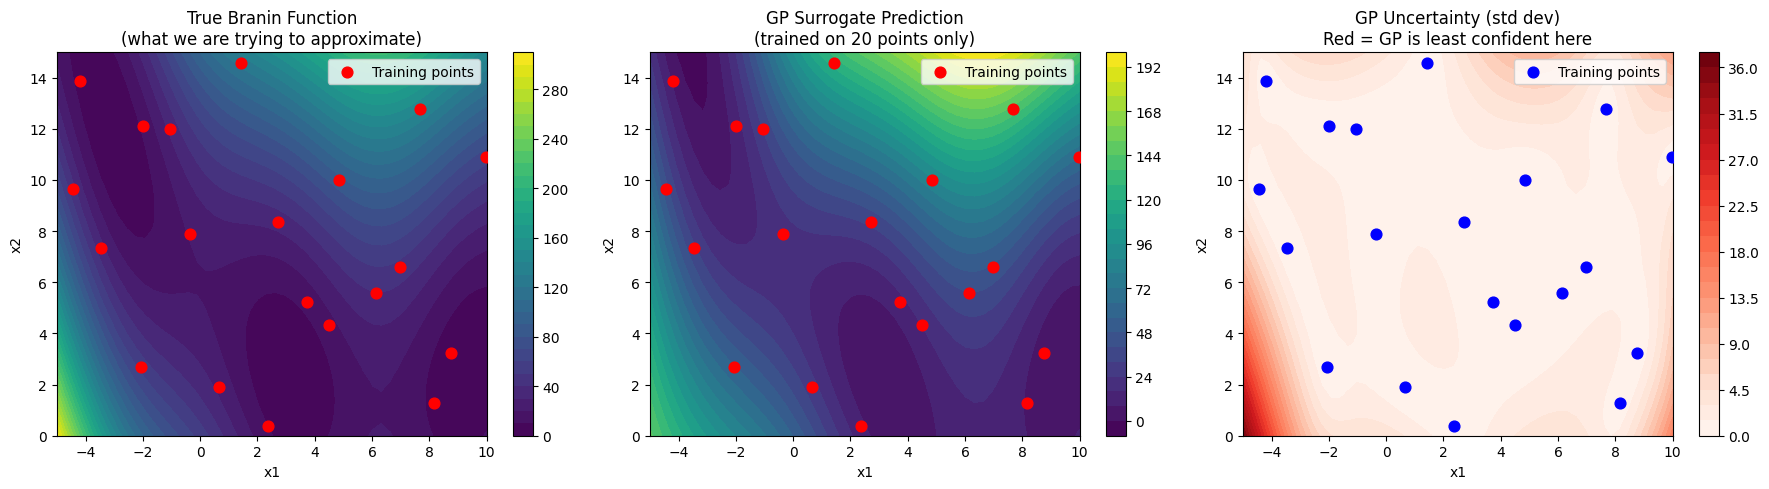

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: True Branin function
im1 = axes[0].contourf(X1, X2, Y_true, levels=30, cmap='viridis')
axes[0].scatter(X[:,0], X[:,1], c='red', s=60,
                label='Training points', zorder=5)
plt.colorbar(im1, ax=axes[0])
axes[0].set_title('True Branin Function\n(what we are trying to approximate)')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].legend()

# Plot 2: GP Surrogate prediction
im2 = axes[1].contourf(X1, X2, Y_pred, levels=30, cmap='viridis')
axes[1].scatter(X[:,0], X[:,1], c='red', s=60,
                label='Training points', zorder=5)
plt.colorbar(im2, ax=axes[1])
axes[1].set_title('GP Surrogate Prediction\n(trained on 20 points only)')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].legend()

# Plot 3: Uncertainty map
im3 = axes[2].contourf(X1, X2, Y_std, levels=30, cmap='Reds')
axes[2].scatter(X[:,0], X[:,1], c='blue', s=60,
                label='Training points', zorder=5)
plt.colorbar(im3, ax=axes[2])
axes[2].set_title('GP Uncertainty (std dev)\nRed = GP is least confident here')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
axes[2].legend()

plt.tight_layout()
plt.savefig('../results/gp_branin_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
from sklearn.metrics import r2_score, mean_squared_error

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("=" * 40)
print("   Surrogate Model Performance")
print("=" * 40)
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print()
if r2 > 0.95:
    print("  Excellent fit! The surrogate captures")
    print("  95%+ of the true function's variance.")
elif r2 > 0.85:
    print("  Good fit. Reasonable approximation")
    print("  with only 20 training points.")
else:
    print("  Moderate fit. Try re-running Cell 3")
    print("  for a better LHS sample placement.")
print("=" * 40)

   Surrogate Model Performance
  RMSE : 15.6923
  R²   : 0.9130

  Good fit. Reasonable approximation
  with only 20 training points.
